Dataset shape: (11611, 14)
Rows after cleaning: 11611

=== PM2.5 Descriptive Statistics ===
              count    mean    std   min    25%    50%    75%    max
city                                                                
Delhi        4244.0  205.21  96.91   5.0  141.0  179.0  251.0  824.0
London       4435.0   49.76  25.14   5.0   35.0   46.0   59.0  542.0
Mexico City  2932.0   71.83  21.76  13.0   57.0   71.0   86.0  175.0

=== Hospital Admissions Descriptive Statistics ===
              count   mean    std   min   25%   50%   75%    max
city                                                            
Delhi        4244.0  80.34  15.40  43.0  70.0  77.0  88.0  177.0
London       4435.0  18.49   2.85  10.0  17.0  18.0  20.0   58.0
Mexico City  2932.0  38.26   4.70  20.0  35.0  38.0  41.0   57.0


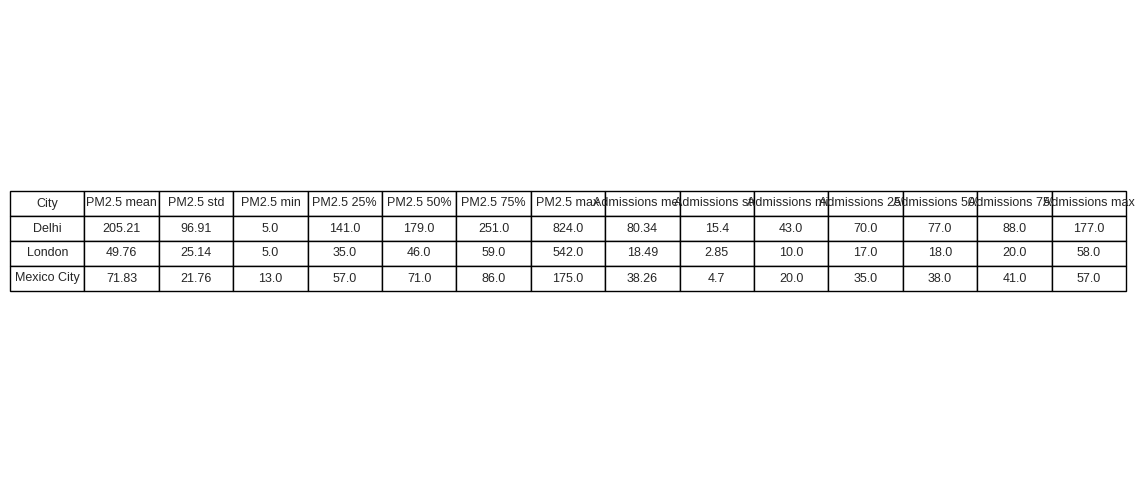

Saved table as image1.png


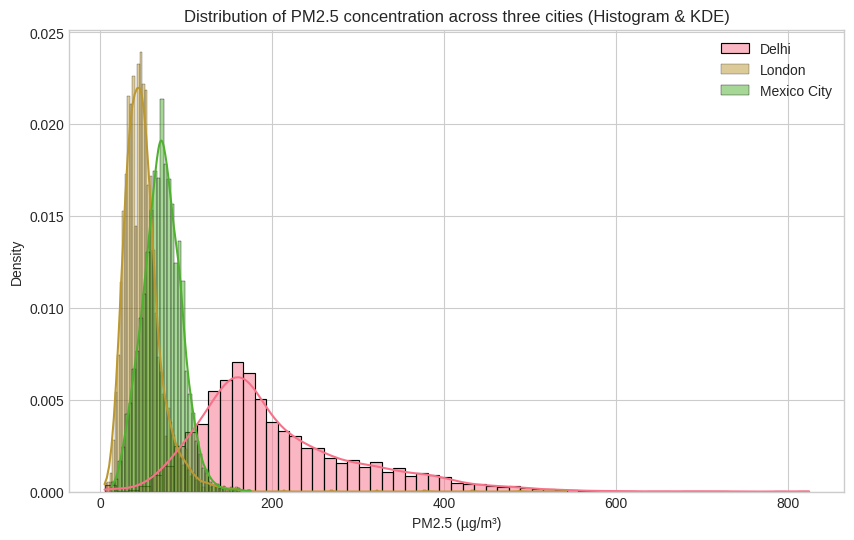

Saved histogram + KDE as image10.png


/tmp/ipykernel_3258/3682434728.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=city_col, y=admission_col, palette='Set2')


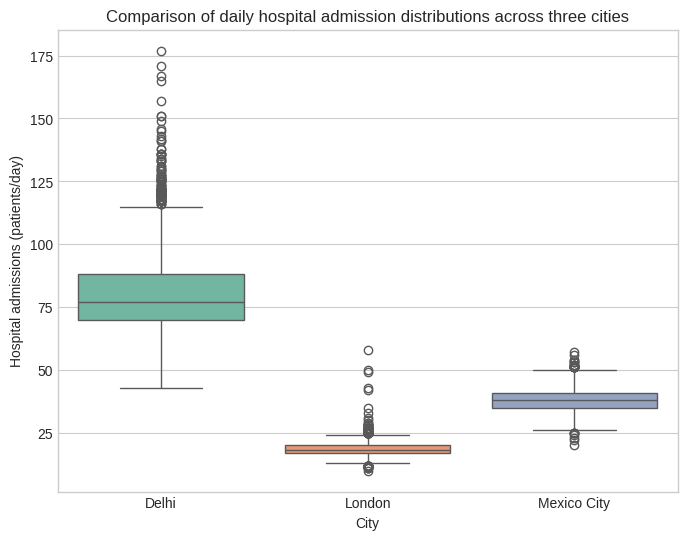

Saved boxplot as image14.png


In [13]:
"""
Descriptive Statistics for three cities (Delhi, London, Mexico City)
Compute summary statistics and generate figures for PM2.5 and hospital admissions.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------
filename = "merged_project_data.csv"   # Change to your file name
df = pd.read_csv(filename)
print(f"Dataset shape: {df.shape}")

# -------------------------------------------------------------------
# 2. PREPARE DATA
# -------------------------------------------------------------------
city_col = 'city'
pm25_col = 'pm25'
admission_col = 'hospital_admissions'

# Keep only needed columns and drop missing
df_clean = df[[city_col, pm25_col, admission_col]].dropna()
print(f"Rows after cleaning: {len(df_clean)}")

# -------------------------------------------------------------------
# 3. COMPUTE DESCRIPTIVE STATISTICS BY CITY
# -------------------------------------------------------------------
stats_pm25 = df_clean.groupby(city_col)[pm25_col].describe()
stats_adm = df_clean.groupby(city_col)[admission_col].describe()

# Combine PM2.5 and admissions stats into one table (optional)
# For clarity, print separately
print("\n=== PM2.5 Descriptive Statistics ===")
print(stats_pm25.round(2))
print("\n=== Hospital Admissions Descriptive Statistics ===")
print(stats_adm.round(2))

# -------------------------------------------------------------------
# 4. SAVE THE FULL STATISTICS TABLE AS IMAGE (image1.png)
#    We'll create a styled table using matplotlib
# -------------------------------------------------------------------
# Create a figure for the table
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

# Build table data: combine PM2.5 and admissions stats side by side
# We'll show: City | PM2.5 mean | PM2.5 std | ... | Admissions mean | etc.
cities = stats_pm25.index.tolist()
pm25_stats = stats_pm25[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)
adm_stats = stats_adm[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)

# Create a merged DataFrame
table_data = []
for city in cities:
    row = [city] + pm25_stats.loc[city].tolist() + adm_stats.loc[city].tolist()
    table_data.append(row)

columns = ['City'] + [f'PM2.5 {c}' for c in pm25_stats.columns] + [f'Admissions {c}' for c in adm_stats.columns]
table = ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
plt.savefig('image1.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved table as image1.png")

# -------------------------------------------------------------------
# 5. HISTOGRAM + KDE FOR PM2.5 (image10.png)
# -------------------------------------------------------------------
plt.figure(figsize=(10, 6))
for city in cities:
    subset = df_clean[df_clean[city_col] == city][pm25_col]
    sns.histplot(subset, kde=True, label=city, alpha=0.5, stat='density')
plt.title('Distribution of PM2.5 concentration across three cities (Histogram & KDE)')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Density')
plt.legend()
plt.savefig('image10.png', dpi=150)
plt.show()
print("Saved histogram + KDE as image10.png")

# -------------------------------------------------------------------
# 6. BOXPLOT FOR HOSPITAL ADMISSIONS (image14.png)
# -------------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x=city_col, y=admission_col, palette='Set2')
plt.title('Comparison of daily hospital admission distributions across three cities')
plt.xlabel('City')
plt.ylabel('Hospital admissions (patients/day)')
plt.savefig('image14.png', dpi=150)
plt.show()
print("Saved boxplot as image14.png")